In [ ]:
import marimo as mo
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from regex import P
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap
from itertools import combinations
from tqdm import tqdm
import os
import re
import yaml
from torchgeodemo import autoencoder_train_latent
import torch
import os
import gdown


#notebook to rest reconstruction error of PCA

random_seed_number = 20210321  # 2021 UK Census date used as random seed
def set_random_seeds(seed):
    # """Set random seeds for reproducibility."""
    torch.manual_seed(seed)  # Set seed for PyTorch
    # np.random.seed(seed)  # Set seed for NumPy
    # random.seed(seed)  # Set seed for Python's random module

    # # If using a GPU, set seeds for CUDA as well
    # torch.cuda.manual_seed(seed)
    # torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    # # Ensure deterministic behavior on GPU
    # torch.backends.cudnn.deterministic = True  # Make sure CUDA uses deterministic algorithms
    # torch.backends.cudnn.benchmark = False  # Avoid using CUDA's autotuning for performance (slower, but more reproducible)

# Set the seed
set_random_seeds(seed=random_seed_number)


# Download the Parquet file from Google Drive
file_id = '1F_vFJfWon15iWZw6l35smt5Jyb2aPeCn'
output = 'OA_All_Census_21.parquet'
# Define the target path
data_path = f"../data/{output}"
# Check if the file already exists
if not os.path.exists(data_path):
    # Download the Parquet file from Google Drive
    gdown.download(f'https://drive.google.com/uc?id={file_id}', data_path, quiet=False)
else:
    print(f"File already exists at {data_path}")

# Read the 2021 census parquet file into a DataFrame
All_census = pd.read_parquet(data_path)
#set OA as index
All_census = All_census.set_index('OA')

# Drop the column 'ts0060001' and store in a new DataFrame called 'W' (weight)
All_W = All_census['ts0060001']
All_census = All_census.drop(columns=['ts0060001'])

# Remove the Wales only variables

# Strings to search for
strings_to_remove = ['ts032', 'ts033', 'ts034', 'ts035', 'ts036', 'ts076']
# Filter columns
columns_to_keep = [col for col in All_census.columns if not any(string in col for string in strings_to_remove)]

# Filter the DataFrame to keep only the desired columns
All_census = All_census[columns_to_keep]

#print columns with missing values
print("Columns with missing values:")
missing_columns = All_census.columns[All_census.isnull().any()].tolist()
print(missing_columns)
# All_census = All_census.fillna(0)
All_census

File already exists at ../data/OA_All_Census_21.parquet
Columns with missing values:
['ts0200002_PCT', 'ts0200003_PCT', 'ts0550002_PCT', 'ts0550003_PCT', 'ts0550004_PCT', 'ts0550005_PCT', 'ts0550006_PCT', 'ts0550007_PCT', 'ts0550008_PCT', 'ts0550009_PCT', 'ts0550010_PCT']


,ts0010002_PCT,ts0010003_PCT,ts0020002_PCT,ts0020003_PCT,ts0020004_PCT,ts0020005_PCT,ts0020006_PCT,ts0020007_PCT,ts0020008_PCT,ts0020009_PCT,...,ts0670007_PCT,ts0670008_PCT,ts0680002_PCT,ts0680003_PCT,ts0750002_PCT,ts0750003_PCT,ts0750004_PCT,ts0750005_PCT,ts0750006_PCT,ts0750007_PCT
OA,,,,,,,,,,,,,,,,,,,,,
E00060274,100.0,0.0,49.740933,30.051813,30.051813,30.051813,0.000000,0.000000,0.000000,0.000000,...,14.583333,4.166667,27.530364,72.469636,25.892857,0.000000,24.107143,38.392857,11.607143,0.000000
E00060275,100.0,0.0,50.819672,34.426230,33.114754,32.459016,0.655738,1.311475,0.000000,1.311475,...,18.421053,1.644737,25.066667,74.933333,21.656051,2.547771,28.025478,32.484076,15.286624,0.000000
E00060276,100.0,0.0,36.619718,43.661972,43.192488,43.192488,0.000000,0.469484,0.000000,0.469484,...,17.757009,2.336449,16.597510,83.402490,28.695652,0.000000,37.391304,29.565217,3.478261,0.869565
E00060277,100.0,0.0,46.411483,36.842105,36.842105,36.842105,0.000000,0.000000,0.000000,0.000000,...,16.346154,1.442308,24.513619,75.486381,33.606557,0.819672,29.508197,23.770492,12.295082,0.000000
E00060279,100.0,0.0,38.839286,41.517857,41.517857,41.517857,0.000000,0.000000,0.000000,0.000000,...,16.289593,2.714932,20.152091,79.847909,28.099174,1.652893,34.710744,23.966942,11.570248,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W00006938,100.0,0.0,23.958333,54.166667,54.166667,54.166667,0.000000,0.000000,0.000000,0.000000,...,39.583333,0.520833,16.037736,83.962264,33.333333,0.980392,27.450980,21.568627,16.666667,0.000000
W00006940,100.0,0.0,30.232558,50.872093,50.290698,50.000000,0.290698,0.581395,0.581395,0.000000,...,27.325581,3.779070,18.069307,81.930693,25.423729,3.389831,27.683616,28.813559,14.689266,0.000000
W00006941,100.0,0.0,39.316239,36.324786,36.324786,35.470085,0.854701,0.000000,0.000000,0.000000,...,19.658120,4.700855,13.909774,86.090226,32.558140,3.100775,20.930233,27.906977,14.728682,0.775194


In [ ]:

# def populate_data_table(filepath: str) -> pd.DataFrame:
#     """
#     Populates a data table by merging CSV files in the specified directory.

#     Args:
#         filepath (str): The path to the directory containing the CSV files.

#     Returns:
#         pd.DataFrame: The merged data table, or None if no files are found.
#     """
#     print("Populating data table from files in", filepath)
#     data_table = None  # Initialize data_table outside the loop
#     # Divide all columns but the first by the second column
#     for file in tqdm(os.listdir(filepath), desc="Processing files", unit="file"):
#         df = pd.read_csv(filepath + "/" + file, index_col="OA")

#         if data_table is None:
#             data_table = df  # Initialize data_table with the first file encountered
#         else:
#             # Merge on index
#             data_table = data_table.merge(df, left_index=True, right_index=True, how="outer")
#     return data_table

# eng_census_raw = populate_data_table("../data/eng_raw_csvs")



Populating data table from files in ../data/eng_raw_csvs


Processing files: 100%|██████████| 52/52 [00:18<00:00,  2.89file/s]


In [ ]:
# import pandas as pd
# import re

# # Your DataFrame
# df = eng_census_raw

# # Extract unique prefixes by removing the last four digits
# prefixes = set(re.sub(r"\d{4}$", "", col) for col in df.columns if re.match(r".*\d{4}$", col))

# # Normalize each group
# for prefix in prefixes:
#     print(f"Normalizing columns with prefix: {prefix}")
#     #if prefix is "ts020": then base col ts0010001
#     if prefix in ["ts020", "ts055", "ts065"]:
#         base_col = "ts0010001"  # The assumed total column

#     base_col = f"{prefix}0001"  # The assumed total column
#     group_cols = [col for col in df.columns if col.startswith(prefix)]

#     if base_col in df.columns:  # Ensure the base column exists
#         df[group_cols] = df[group_cols].div(df[base_col], axis=0)

# # # Save or use the transformed DataFrame
# df.to_csv("normalized_eng_census.csv", index=False)  # Adjust as needed


Normalizing columns with prefix: ts059
Normalizing columns with prefix: ts063
Normalizing columns with prefix: ts003
Normalizing columns with prefix: ts005
Normalizing columns with prefix: ts019
Normalizing columns with prefix: ts029
Normalizing columns with prefix: ts067
Normalizing columns with prefix: ts018
Normalizing columns with prefix: ts020
Normalizing columns with prefix: ts038
Normalizing columns with prefix: ts046
Normalizing columns with prefix: ts037
Normalizing columns with prefix: ts023
Normalizing columns with prefix: ts052
Normalizing columns with prefix: ts032
Normalizing columns with prefix: ts007a
Normalizing columns with prefix: ts050
Normalizing columns with prefix: ts068
Normalizing columns with prefix: ts040
Normalizing columns with prefix: ts066
Normalizing columns with prefix: ts004
Normalizing columns with prefix: ts075
Normalizing columns with prefix: ts065
Normalizing columns with prefix: ts051
Normalizing columns with prefix: ts056
Normalizing columns with

In [4]:
def get_pca_filter_columns(All_census):

    # Filter columns with 'ts' in their names.
    ts_columns = [col for col in All_census.columns if 'ts' in col]
    ts_data = All_census[ts_columns]

    # Standardize the data.
    scaler = StandardScaler()
    ts_data_std = scaler.fit_transform(ts_data)

    # Apply PCA to account for 80% of the variance.
    pca = PCA(n_components=0.8)  # Adjusted to select components for 80% variance.
    pca.fit(ts_data_std)

    # The explained variance ratio indicates the importance of each principal component.
    explained_variance_ratio = pca.explained_variance_ratio_

    # Number of components chosen.
    num_components_chosen = pca.n_components_

    # Components_ gives the loadings of each variable on the principal components.
    loadings = pca.components_

    # Calculate the overall importance of each variable within the chosen components.
    # This is done by summing the squares of the loadings across the chosen components for each variable.
    overall_importance = np.sum(loadings**2, axis=0)

    # Identify the indices of the most important variables based on overall importance within the chosen components.
    important_indices = np.argsort(overall_importance)[::-1][:min(200, num_components_chosen)]

    # Extract the names of the most important variables.
    important_variables = np.array(ts_columns)[important_indices]

    return important_variables



In [5]:
def get_high_variance_columns(All_census,var_threshold=1.2):
    variances = {col: All_census[col].var() for col in All_census if col.startswith("ts")}

# Store variances in a new DataFrame
    var_df = pd.DataFrame(list(variances.items()), columns=['Column', 'Variance'])

# Find the median variance
#median_variance = All_census.var().median()  # this raises an error
    median_variance = var_df['Variance'].median() # I assume this is the aim, based on the comment and code above

# Determine 20% higher than the median variance
    threshold_variance = median_variance * var_threshold

# Subset the original DataFrame to include columns 20% higher than the median variance
    selected_columns = [col for col, var in variances.items() if var > threshold_variance]

    return selected_columns


In [22]:



important_variables = get_pca_filter_columns(All_census)
selected_columns = get_high_variance_columns(All_census)
#print All_census columns
print("PCA important variables:")
print(important_variables)
print("High variance columns:")
print(selected_columns)
print("All columns:")
print(All_census.columns.to_list())

# #  Select all the "important" variables based on PCA and varience
# concatenated_columns = np.unique(np.concatenate((important_variables, selected_columns)))
#only run varience prefileter
concatenated_columns = selected_columns
#dont have either
concatenated_columns = All_census.columns.to_list()


subset_df = All_census[concatenated_columns]
#subset_df

# Scale values [0, 1]
df_scaled = subset_df / 100.0

#round to 3dp 
df_scaled = df_scaled.round(3)
df_scaled = df_scaled.reset_index() #OA to col
# Save the scaled DataFrame to a CSV file
cleaned_data_path = "../data/engcensus_cleaned_scaled.parquet"
df_scaled.to_parquet(cleaned_data_path, index=False)
print(f"Scaled DataFrame saved to {cleaned_data_path}")

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [5]:
#load the cleaned data
cleaned_data_path = "../data/engcensus_cleaned_scaled.parquet"
df_scaled = pd.read_parquet(cleaned_data_path)
df_scaled

,OA,ts0010002_PCT,ts0010003_PCT,ts0020002_PCT,ts0020003_PCT,ts0020004_PCT,ts0020005_PCT,ts0020006_PCT,ts0020007_PCT,ts0020008_PCT,...,ts0670007_PCT,ts0670008_PCT,ts0680002_PCT,ts0680003_PCT,ts0750002_PCT,ts0750003_PCT,ts0750004_PCT,ts0750005_PCT,ts0750006_PCT,ts0750007_PCT
0,E00060274,1.0,0.0,0.497,0.301,0.301,0.301,0.000,0.000,0.000,...,0.146,0.042,0.275,0.725,0.259,0.000,0.241,0.384,0.116,0.000
1,E00060275,1.0,0.0,0.508,0.344,0.331,0.325,0.007,0.013,0.000,...,0.184,0.016,0.251,0.749,0.217,0.025,0.280,0.325,0.153,0.000
2,E00060276,1.0,0.0,0.366,0.437,0.432,0.432,0.000,0.005,0.000,...,0.178,0.023,0.166,0.834,0.287,0.000,0.374,0.296,0.035,0.009
3,E00060277,1.0,0.0,0.464,0.368,0.368,0.368,0.000,0.000,0.000,...,0.163,0.014,0.245,0.755,0.336,0.008,0.295,0.238,0.123,0.000
4,E00060279,1.0,0.0,0.388,0.415,0.415,0.415,0.000,0.000,0.000,...,0.163,0.027,0.202,0.798,0.281,0.017,0.347,0.240,0.116,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188875,W00006938,1.0,0.0,0.240,0.542,0.542,0.542,0.000,0.000,0.000,...,0.396,0.005,0.160,0.840,0.333,0.010,0.275,0.216,0.167,0.000
188876,W00006940,1.0,0.0,0.302,0.509,0.503,0.500,0.003,0.006,0.006,...,0.273,0.038,0.181,0.819,0.254,0.034,0.277,0.288,0.147,0.000
188877,W00006941,1.0,0.0,0.393,0.363,0.363,0.355,0.009,0.000,0.000,...,0.197,0.047,0.139,0.861,0.326,0.031,0.209,0.279,0.147,0.008
188878,W00006942,1.0,0.0,0.479,0.335,0.335,0.335,0.000,0.000,0.000,...,0.160,0.043,0.240,0.760,0.269,0.023,0.169,0.415,0.115,0.008


In [70]:
def gen_layer_sizes(input_size,latent_size,num_layers,scaling_type = "mul"):

    """
    Generate layer sizes for a neural network based on the input size, latent size, number of layers, and scaling type.

    Args:
        input_size (int): The size of the input layer.
        latent_size (int): The size of the latent layer.
        num_layers (int): The number of layers in the network.
        scaling_type (str): The type of scaling to use. Can be "geo" or "lin".

    Returns:
        list: A list containing the sizes of each layer in the network.
    """
    if scaling_type == "mul":
        # Geometric scaling
        scale_factor = (latent_size / input_size) ** (1 / (num_layers - 1))
        layer_sizes = [int(input_size * scale_factor ** i) for i in range(num_layers)]
    elif scaling_type == "lin":
        # Linear scaling
        step = (latent_size - input_size) / (num_layers - 1)
        layer_sizes = [int(input_size + step * i) for i in range(num_layers)]
    else:
        raise ValueError("Invalid scaling type. Use 'mul' or 'lin'.")

    #for torchgeodemo dont want to include the input layer
    layer_sizes = layer_sizes[1:]  # Exclude input layer size
    return layer_sizes




In [87]:


epochs = 200
scaling_type = "lin"
run_name = f"{epochs}epoch_scan_alleng_{scaling_type}"
WORKING_DIR = "../engcensus/" + run_name
os.makedirs(WORKING_DIR, exist_ok=True)
# Output directory for generated YAMLs
OUTPUT_DIR = "../engcensus/" + run_name + "/yamls"
os.makedirs(OUTPUT_DIR, exist_ok=True)


input_size = len(df_scaled.columns)-1
bottleneck_sizes = [200]
encoder_layer_sizes = []
for bottleneck_size in bottleneck_sizes:
    encoder_layer_sizes.append(gen_layer_sizes(input_size, bottleneck_size, 4, scaling_type=scaling_type))

def plot_loss(WORKING_DIR,data_nickname,ae_nickname):
    # Load the loss data
    loss_data = pd.read_csv(WORKING_DIR + f"/logs/log_{data_nickname}_{ae_nickname}_v1/version_1/metrics.csv")[['epoch', 'train_loss_epoch', 'recon_loss_epoch']]
    #drop rows with nan
    loss_data = loss_data.dropna()
    plt.plot(loss_data["epoch"], loss_data["train_loss_epoch"], label="Training Loss")
    plt.plot(loss_data["epoch"], loss_data["recon_loss_epoch"], label="Reconstruction Loss")
    plt.show()



geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [200, 276, 352]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [352, 276, 200]}, 'max_epochs': 200, 'nickname': 'bottleneck_200', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/200epoch_scan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [200, 276, 352, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=352, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=352, out_features=276, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=276, out_features=200, bias=True)
    

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 304 K  | train
2 | decoder       | MLP     | 304 K  | train
--------------------------------------------------
608 K     Trainable params
0         Non-trainable params
608 K     Total params
2.434     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


Reconstruction errors saved to ../engcensus/200epoch_scan_alleng_lin/census_geodemo__bottleneck_200_v1__recon_error.csv
Original inputs saved to ../engcensus/200epoch_scan_alleng_lin/census_geodemo__bottleneck_200_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/200epoch_scan_alleng_lin/census_geodemo__bottleneck_200_v1__reconstructed_outputs.csv


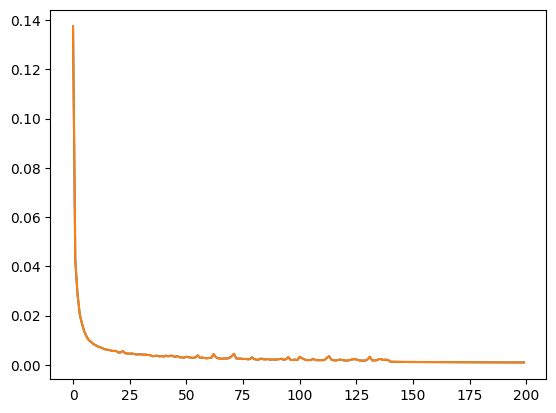

In [88]:
# Set the seed
set_random_seeds(seed=random_seed_number)
# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": cleaned_data_path,
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        },
        "decoder": {
            "sizes":  "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}

data_nickname = "census_geodemo"
# Generate YAML files with varying latent space sizes
for encoder_layer_size in encoder_layer_sizes:
    _latent_size = encoder_layer_size[-1]  # Last element is the bottleneck size
    ae_nickname = f"bottleneck_{_latent_size}"
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_layer_size
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_layer_size[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname

    config_path = os.path.join(OUTPUT_DIR, f"config_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)

    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [2, 11, 71]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [71, 11, 2], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 1}}, 'max_epochs': 60, 'nickname': 'bottleneck_2', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 1, 'use_covariance_loss': False, 'decoder_sizes': [2, 11, 71, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=71, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=71, out_features=11, bias=True)
      (3): Leak

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 31.3 K | train
2 | decoder       | MLP     | 31.8 K | train
--------------------------------------------------
63.1 K    Trainable params
0         Non-trainable params
63.1 K    Total params
0.252     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_2_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_2_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_2_v1__reconstructed_outputs.csv


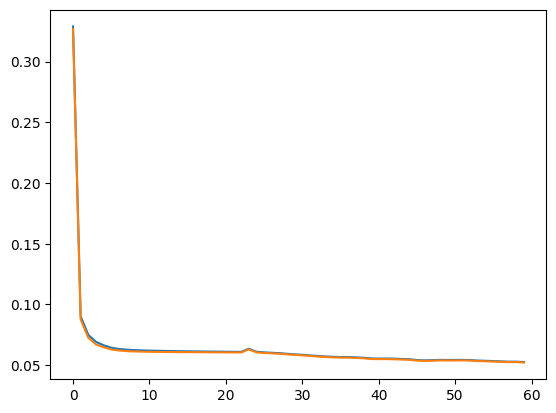


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [4, 19, 90]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [90, 19, 4], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 2}}, 'max_epochs': 60, 'nickname': 'bottleneck_4', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 2, 'use_covariance_loss': False, 'decoder_sizes': [4, 19, 90, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=90, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=90, out_features=19, bias=True)
      (3): Leak

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 40.5 K | train
2 | decoder       | MLP     | 40.9 K | train
--------------------------------------------------
81.4 K    Trainable params
0         Non-trainable params
81.4 K    Total params
0.326     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_4_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_4_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_4_v1__reconstructed_outputs.csv


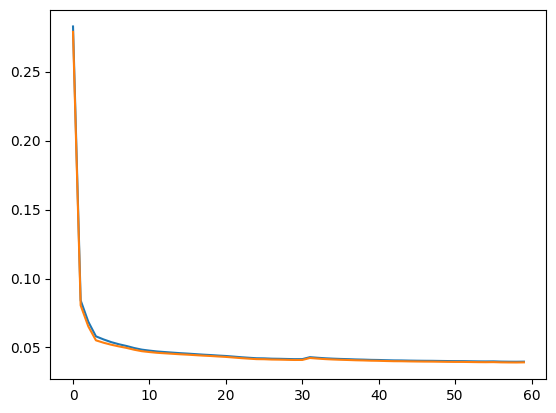


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [8, 30, 113]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [113, 30, 8], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 4}}, 'max_epochs': 60, 'nickname': 'bottleneck_8', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 4, 'use_covariance_loss': False, 'decoder_sizes': [8, 30, 113, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=113, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=113, out_features=30, bias=True)
      (3):

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 52.3 K | train
2 | decoder       | MLP     | 52.7 K | train
--------------------------------------------------
104 K     Trainable params
0         Non-trainable params
104 K     Total params
0.420     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_8_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_8_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_8_v1__reconstructed_outputs.csv


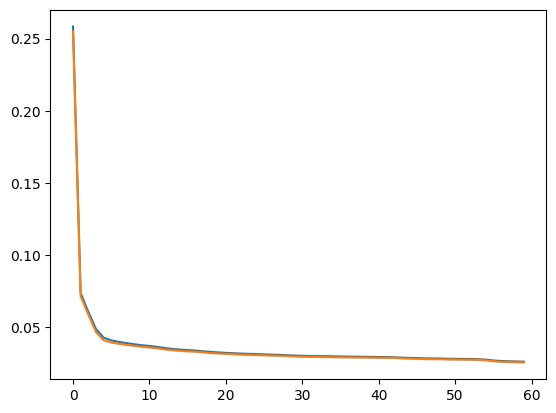


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [16, 47, 143]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [143, 47, 16], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 8}}, 'max_epochs': 60, 'nickname': 'bottleneck_16', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 8, 'use_covariance_loss': False, 'decoder_sizes': [16, 47, 143, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=143, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=143, out_features=47, bias=True)
      

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 69.0 K | train
2 | decoder       | MLP     | 69.4 K | train
--------------------------------------------------
138 K     Trainable params
0         Non-trainable params
138 K     Total params
0.554     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_16_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_16_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_16_v1__reconstructed_outputs.csv


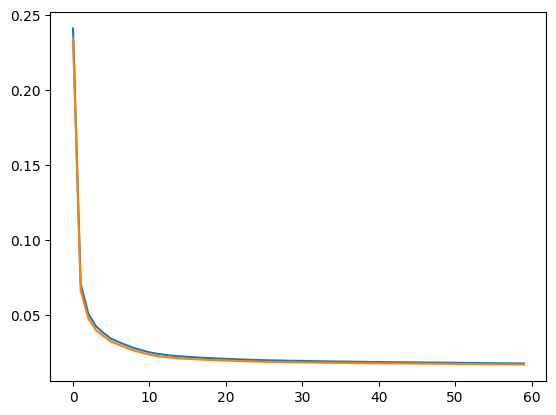


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 76, 180]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [180, 76, 32], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 16}}, 'max_epochs': 60, 'nickname': 'bottleneck_32', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 16, 'use_covariance_loss': False, 'decoder_sizes': [32, 76, 180, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=180, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=180, out_features=76, bias=True)
    

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 93.6 K | train
2 | decoder       | MLP     | 94.0 K | train
--------------------------------------------------
187 K     Trainable params
0         Non-trainable params
187 K     Total params
0.751     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_32_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_32_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_32_v1__reconstructed_outputs.csv


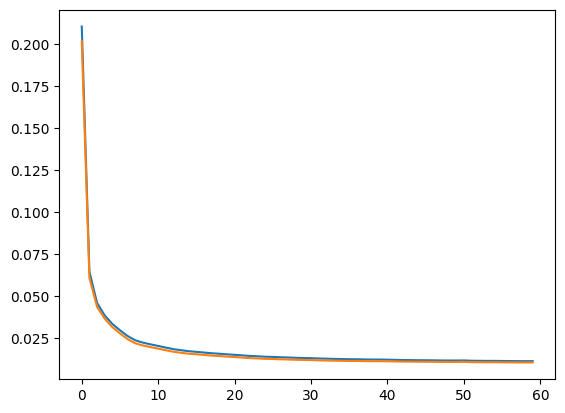


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [64, 120, 227]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [227, 120, 64], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 32}}, 'max_epochs': 60, 'nickname': 'bottleneck_64', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 32, 'use_covariance_loss': False, 'decoder_sizes': [64, 120, 227, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=227, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=227, out_features=120, bias=True)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 132 K  | train
2 | decoder       | MLP     | 133 K  | train
--------------------------------------------------
265 K     Trainable params
0         Non-trainable params
265 K     Total params
1.063     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_64_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_64_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_64_v1__reconstructed_outputs.csv


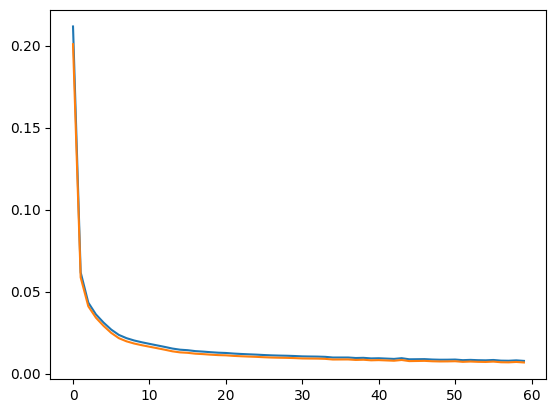


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 191, 286]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [286, 191, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'use_covariance_loss': False, 'decoder_sizes': [128, 191, 286, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=286, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=286, out_features=191, bias=Tr

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 202 K  | train
2 | decoder       | MLP     | 202 K  | train
--------------------------------------------------
405 K     Trainable params
0         Non-trainable params
405 K     Total params
1.620     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_128_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_128_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparse__bottleneck_128_v1__reconstructed_outputs.csv


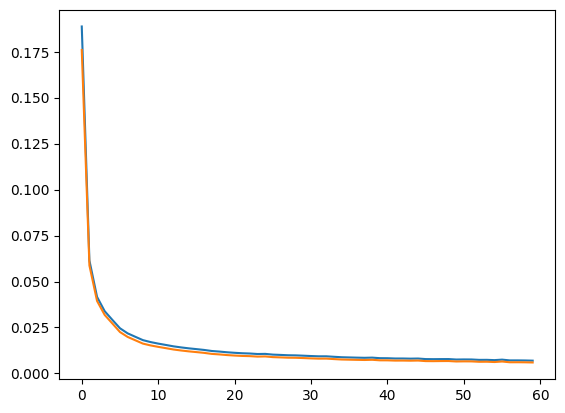

In [129]:
set_random_seeds(seed=random_seed_number)


# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": cleaned_data_path,
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01
            }
        },
        "decoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}


data_nickname = "census_geodemo_sparse"



# Generate YAML files with varying latent space sizes
for encoder_layer_size in encoder_layer_sizes:
    _latent_size = encoder_layer_size[-1]  # Last element is the bottleneck size
    ae_nickname = f"bottleneck_{_latent_size}"
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_layer_size
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_layer_size[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = int(_latent_size/2)


    config_path = os.path.join(OUTPUT_DIR, f"config_{data_nickname}_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)


    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [2, 11, 71]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [71, 11, 2], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 1}}, 'max_epochs': 60, 'nickname': 'bottleneck_2', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 1, 'decoder_sizes': [2, 11, 71, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=71, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=71, out_features=11, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 31.3 K | train
2 | decoder       | MLP     | 31.8 K | train
--------------------------------------------------
63.1 K    Trainable params
0         Non-trainable params
63.1 K    Total params
0.252     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_2_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_2_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_2_v1__reconstructed_outputs.csv


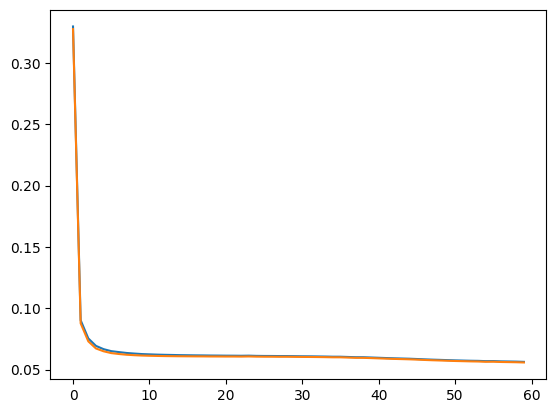


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [4, 19, 90]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [90, 19, 4], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 2}}, 'max_epochs': 60, 'nickname': 'bottleneck_4', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 2, 'decoder_sizes': [4, 19, 90, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=90, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=90, out_features=19, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 40.5 K | train
2 | decoder       | MLP     | 40.9 K | train
--------------------------------------------------
81.4 K    Trainable params
0         Non-trainable params
81.4 K    Total params
0.326     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_4_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_4_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_4_v1__reconstructed_outputs.csv


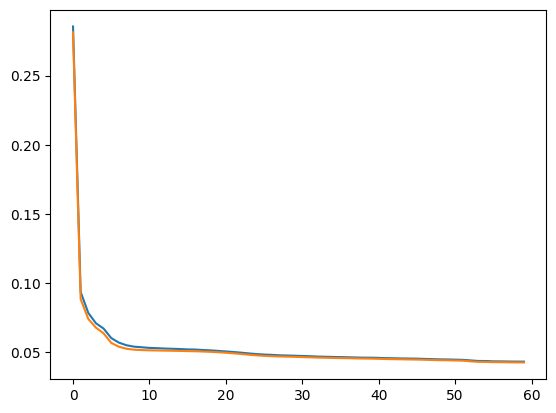


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [8, 30, 113]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [113, 30, 8], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 4}}, 'max_epochs': 60, 'nickname': 'bottleneck_8', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 4, 'decoder_sizes': [8, 30, 113, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=113, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=113, out_features=30, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_feat

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 52.3 K | train
2 | decoder       | MLP     | 52.7 K | train
--------------------------------------------------
104 K     Trainable params
0         Non-trainable params
104 K     Total params
0.420     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_8_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_8_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_8_v1__reconstructed_outputs.csv


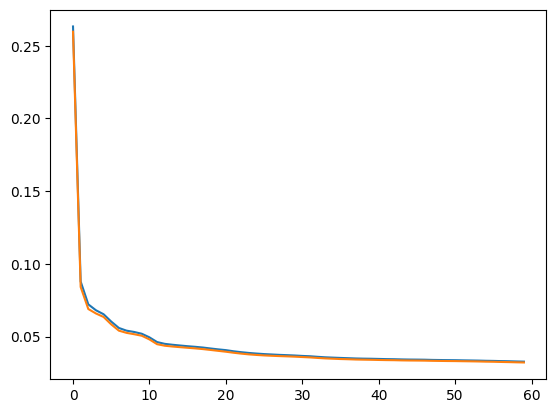


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [16, 47, 143]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [143, 47, 16], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 8}}, 'max_epochs': 60, 'nickname': 'bottleneck_16', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 8, 'decoder_sizes': [16, 47, 143, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=143, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=143, out_features=47, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 69.0 K | train
2 | decoder       | MLP     | 69.4 K | train
--------------------------------------------------
138 K     Trainable params
0         Non-trainable params
138 K     Total params
0.554     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_16_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_16_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_16_v1__reconstructed_outputs.csv


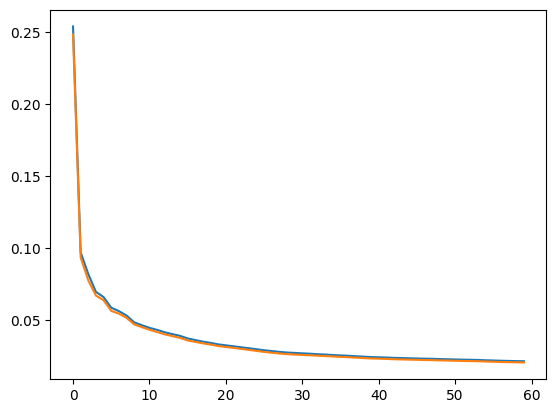


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 76, 180]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [180, 76, 32], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 16}}, 'max_epochs': 60, 'nickname': 'bottleneck_32', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 16, 'decoder_sizes': [32, 76, 180, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=180, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=180, out_features=76, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(i

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 93.6 K | train
2 | decoder       | MLP     | 94.0 K | train
--------------------------------------------------
187 K     Trainable params
0         Non-trainable params
187 K     Total params
0.751     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_32_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_32_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_32_v1__reconstructed_outputs.csv


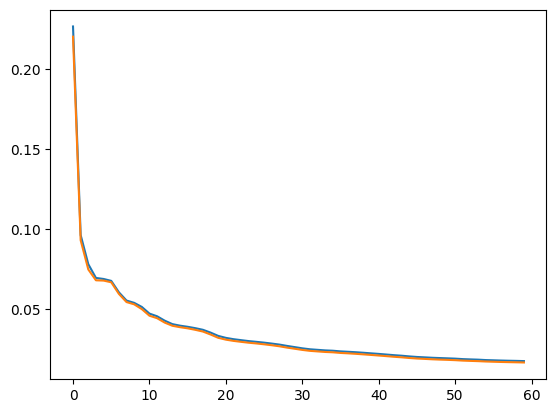


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [64, 120, 227]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [227, 120, 64], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 32}}, 'max_epochs': 60, 'nickname': 'bottleneck_64', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 32, 'decoder_sizes': [64, 120, 227, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=227, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=227, out_features=120, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Line

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 132 K  | train
2 | decoder       | MLP     | 133 K  | train
--------------------------------------------------
265 K     Trainable params
0         Non-trainable params
265 K     Total params
1.063     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_64_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_64_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_64_v1__reconstructed_outputs.csv


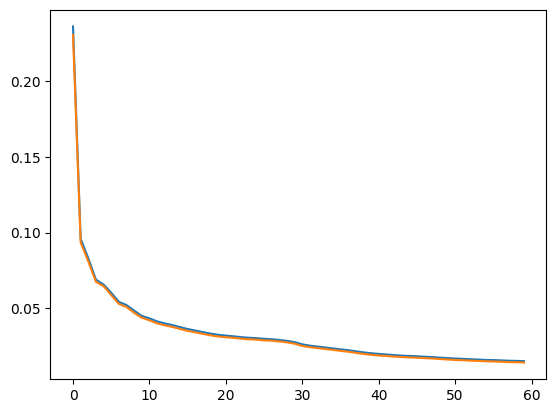


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 191, 286]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [286, 191, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_scan_alleng_mul'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'decoder_sizes': [128, 191, 286, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=286, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=286, out_features=191, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 202 K  | train
2 | decoder       | MLP     | 202 K  | train
--------------------------------------------------
405 K     Trainable params
0         Non-trainable params
405 K     Total params
1.620     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_128_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_128_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_scan_alleng_mul/census_geodemo_sparsecov__bottleneck_128_v1__reconstructed_outputs.csv


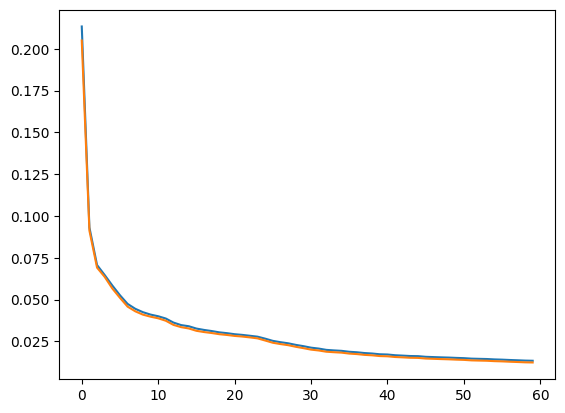

In [130]:
set_random_seeds(seed=random_seed_number)


# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": cleaned_data_path,
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01
            }
        },
        "decoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}


data_nickname = "census_geodemo_sparsecov"

# Generate YAML files with varying latent space sizes
for encoder_layer_size in encoder_layer_sizes:
    _latent_size = encoder_layer_size[-1]  # Last element is the bottleneck size
    ae_nickname = f"bottleneck_{_latent_size}"
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_layer_size
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_layer_size[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = int(_latent_size/2)


    config_path = os.path.join(OUTPUT_DIR, f"config_{data_nickname}_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)


    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)

In [ ]:
bottleneck_sizes = [200]

# Initialize lists to store RMSE and MAE
errors = {}

data_table = pd.read_parquet(cleaned_data_path)
# Set the index to 'OA'
data_table = data_table.set_index('OA')
n_features = data_table.shape[1]
data = data_table
def compute_errors(original, reconstructed):
    """Compute RMSE and MAE between original and reconstructed data."""
    error = original - reconstructed
    return np.sqrt(np.mean(error ** 2)), ((error ** 2).mean(axis =1)/(original**2).mean(axis=1)).mean()

#standardize the data
scaler = StandardScaler()
data_std = scaler.fit_transform(data)
# Fit PCA once with the maximum number of components
pca = PCA(n_components=n_features - 1)
transformed = pca.fit_transform(data_std)

# Process PCA reconstruction
errors["PCA"] = {"rmse": [], "nmse": []}
for n in tqdm(bottleneck_sizes, desc="Processing PCA"):
    reconstructed_pca = (transformed[:, :n] @ pca.components_[:n]) + pca.mean_
    #reconstruct the data
    reconstructed_pca = scaler.inverse_transform(reconstructed_pca)
    print(len(pca.mean_))
    #save the reconstructed data
    pd.DataFrame(reconstructed_pca, index=data.index, columns=data.columns).to_csv(f"../data/PCA/{n}_components.csv")
    rmse, mae = compute_errors(data, reconstructed_pca)
    errors["PCA"]["rmse"].append(rmse)
    errors["PCA"]["nmse"].append(mae)

pca = PCA(n_components=n_features - 1)
transformed = pca.fit_transform(data)

# Process PCA reconstruction
errors["PCA_unscaled"] = {"rmse": [], "nmse": []}
for n in tqdm(bottleneck_sizes, desc="Processing PCA"):
    reconstructed_pca = (transformed[:, :n] @ pca.components_[:n]) + pca.mean_
    #reconstruct the data
    print(len(pca.mean_))
    #save the reconstructed data
    pd.DataFrame(reconstructed_pca, index=data.index, columns=data.columns).to_csv(f"../data/PCA_unscaled/{n}_components.csv")
    rmse, mae = compute_errors(data, reconstructed_pca)
    errors["PCA_unscaled"]["rmse"].append(rmse)
    errors["PCA_unscaled"]["nmse"].append(mae)


429


Processing PCA: 100%|██████████| 1/1 [01:41<00:00, 101.43s/it]


429


Processing PCA: 100%|██████████| 1/1 [01:38<00:00, 98.00s/it]


PCA_unscaled - 2 components: RMSE = 0.06, NMSE = 0.05


PCA_unscaled - 4 components: RMSE = 0.05, NMSE = 0.04


PCA_unscaled - 8 components: RMSE = 0.04, NMSE = 0.03


PCA_unscaled - 16 components: RMSE = 0.03, NMSE = 0.02


PCA_unscaled - 32 components: RMSE = 0.02, NMSE = 0.01


...

Autoencoder (60) - 32 components: RMSE = 0.02, NMSE = 0.01


Autoencoder (60) - 64 components: RMSE = 0.01, NMSE = 0.00


Autoencoder (60) - 128 components: RMSE = 0.01, NMSE = 0.00


Processing Autoencoder (60): 100%|██████████| 8/8 [01:04<00:00,  8.03s/it]

Autoencoder (60) - 200 components: RMSE = 0.01, NMSE = 0.00


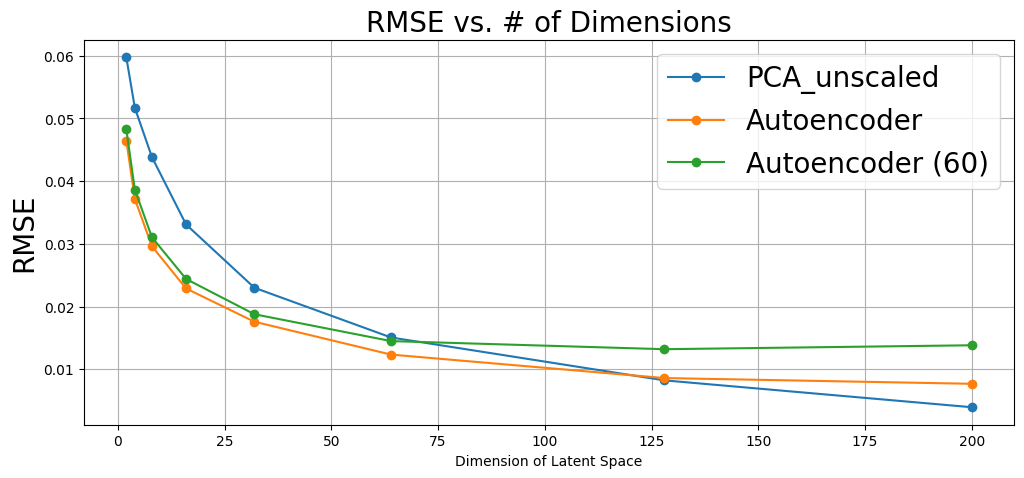

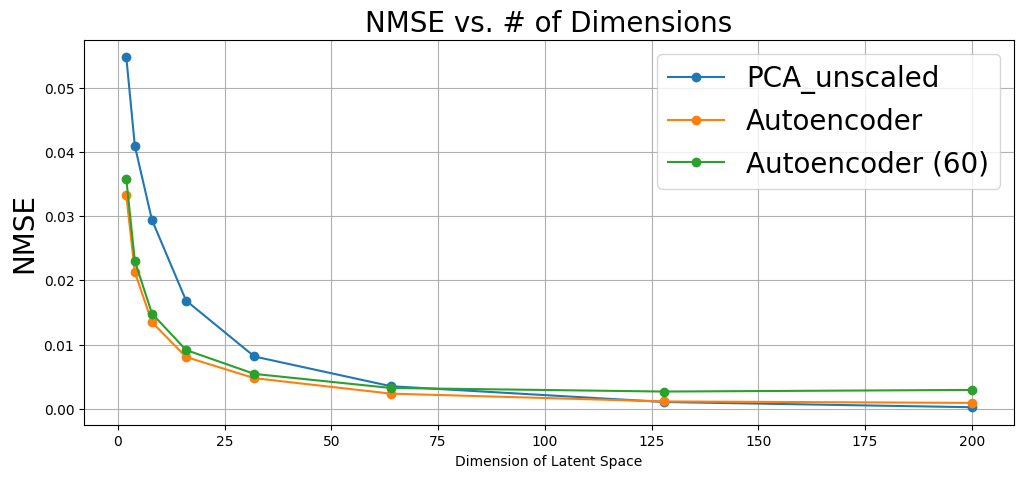

In [90]:
bottleneck_sizes = [2,4,8,16,32,64,128,200]

run_name = "200epoch_scan_alleng_lin"
WORKING_DIR = "../engcensus/" + run_name
os.makedirs(WORKING_DIR, exist_ok=True)
# Output directory for generated YAMLs
OUTPUT_DIR = "../engcensus/" + run_name + "/yamls"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def load_reconstructed_data(file_path):
    """Load reconstructed data from a CSV file."""
    return pd.read_csv(file_path, index_col="ID")

def process_reconstruction(label, file_pattern, bottleneck_sizes, original_data):
    """Process reconstruction for a given method and store errors."""
    errors[label] = {"rmse": [], "nmse": []}
    for n in tqdm(bottleneck_sizes, desc=f"Processing {label}"):
        reconstructed = load_reconstructed_data(file_pattern.format(n=n))
        rmse, nmse = compute_errors(original_data, reconstructed)
        print(f"{label} - {n} components: RMSE = {rmse:.2f}, NMSE = {nmse.mean():.2f}")
        errors[label]["rmse"].append(rmse)
        errors[label]["nmse"].append(nmse.mean())
#load PCA

def process_pca_reconstruction(label, file_pattern, bottleneck_sizes, original_data):
    """Process reconstruction for a given method and store errors."""
    errors[label] = {"rmse": [], "nmse": []}
    for n in tqdm(bottleneck_sizes, desc=f"Processing {label}"):
        reconstructed = pd.read_csv(file_pattern.format(n=n), index_col="OA")
        rmse, nmse = compute_errors(original_data, reconstructed)
        print(f"{label} - {n} components: RMSE = {rmse:.2f}, NMSE = {nmse.mean():.2f}")
        errors[label]["rmse"].append(rmse)
        errors[label]["nmse"].append(nmse.mean())
def plot_errors(metric, ylabel, title):
    """Plot errors for different reconstruction methods."""
    for label, data in errors.items():
        plt.plot(bottleneck_sizes, data[metric], marker='o', label=label)
    plt.xlabel("Dimension of Latent Space")
    plt.ylabel(ylabel,fontsize=20)
    plt.title(title,fontsize=20)
    plt.legend(fontsize=20)
    plt.grid()

# Initialize lists to store RMSE and MAE
errors = {}
# process_pca_reconstruction("PCA", "../data/PCA/{n}_components.csv", bottleneck_sizes, data)
process_pca_reconstruction("PCA_unscaled", "../data/PCA_unscaled/{n}_components.csv", bottleneck_sizes, data)
# Process Autoencoder reconstructions
process_reconstruction("Autoencoder", f"{WORKING_DIR}/census_geodemo__bottleneck_{{n}}_v1__reconstructed_outputs.csv", bottleneck_sizes, data)
run_name = "60epoch_scan_alleng_lin"
WORKING_DIR = "../engcensus/" + run_name
process_reconstruction("Autoencoder (60)", f"{WORKING_DIR}/census_geodemo__bottleneck_{{n}}_v1__reconstructed_outputs.csv", bottleneck_sizes, data)
# process_reconstruction("Autoencoder (Top K)", f"{WORKING_DIR}/census_geodemo_sparse__bottleneck_{{n}}_v1__reconstructed_outputs.csv", bottleneck_sizes, data)
# process_reconstruction("Autoencoder (sparce_cov)", f"{WORKING_DIR}/census_geodemo_sparsecov__bottleneck_{{n}}_v1__reconstructed_outputs.csv", bottleneck_sizes, data)



# Generate plots
plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
plot_errors("rmse", "RMSE", "RMSE vs. # of Dimensions")
plt.show()
plt.figure(figsize=(12, 5))
plot_errors("nmse", "NMSE", "NMSE vs. # of Dimensions")
plt.show()
# plt.subplot(1, 2, 2)
# plot_errors("mae", "MAE", "MAE vs. # of Dimensions")

# plt.tight_layout()
# plt.show()


In [77]:
WORKING_DIR

'../engcensus/60epoch_scan_alleng_lin'

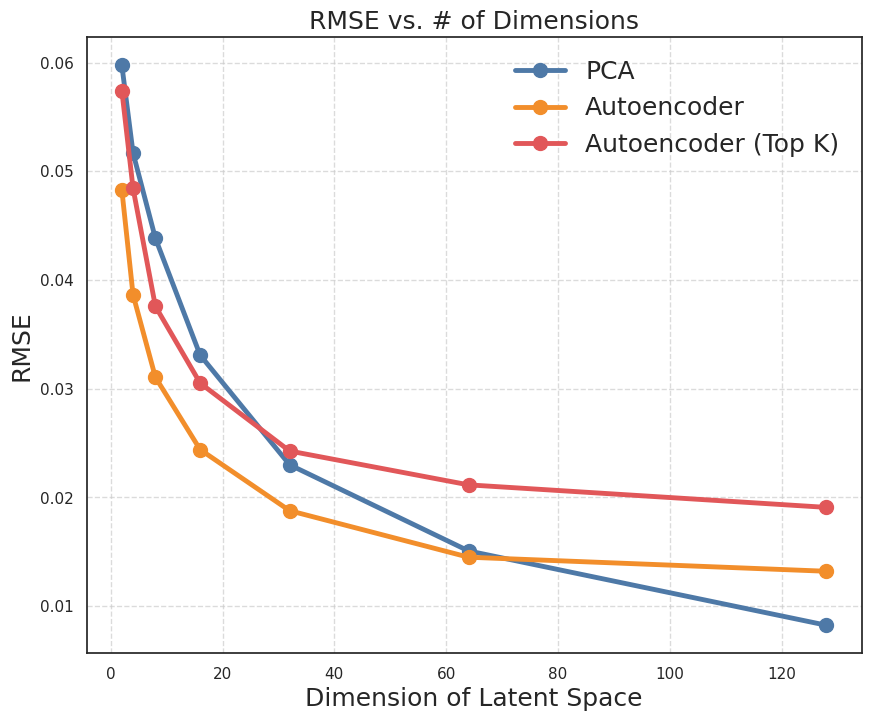

In [46]:
import matplotlib.pyplot as plt

def plot_errors(metric, ylabel, title):
    """Plot errors for different reconstruction methods."""
    colors = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC949"]  # Good contrast & distinct colors
    plt.figure(figsize=(10, 8))
    
    for i, (label, data) in enumerate(errors.items()):
        plt.plot(
            bottleneck_sizes, data[metric], 
            marker='o', markersize=10, linewidth=3.5, 
            label=label, color=colors[i % len(colors)]
        )
    
    plt.xlabel("Dimension of Latent Space", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=18, frameon=False)
    plt.grid(True, linestyle="--", alpha=0.7)

# Generate plot
plot_errors("rmse", "RMSE", "RMSE vs. # of Dimensions")
plt.show()


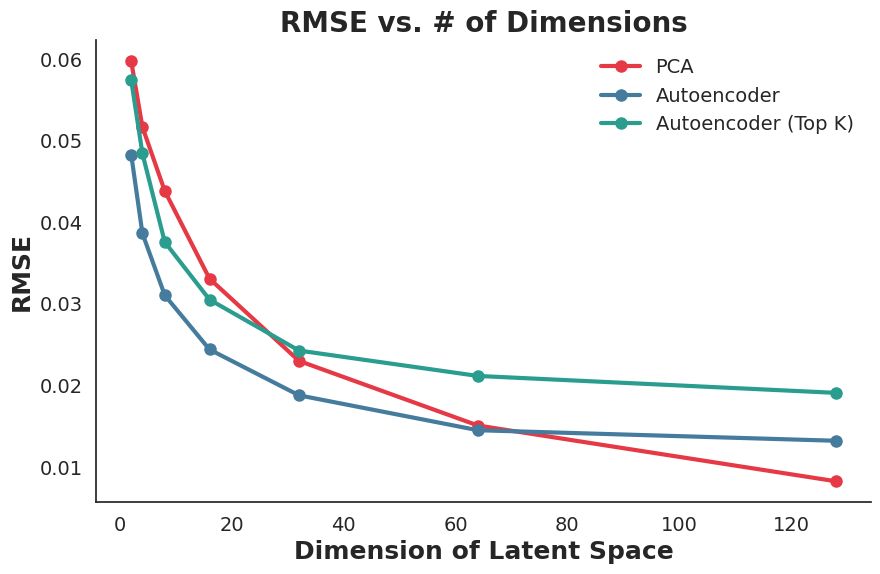

In [44]:
import matplotlib.pyplot as plt

def plot_errors(metric, ylabel, title):
    """Plot errors for different reconstruction methods."""
    plt.figure(figsize=(10, 6))  # Adjust figure size
    colors = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261", "#264653"]  # Custom color palette

    for (label, data), color in zip(errors.items(), colors):
        plt.plot(bottleneck_sizes, data[metric], 
                 marker='o', markersize=8, linewidth=3, 
                 label=label, color=color)

    plt.xlabel("Dimension of Latent Space", fontsize=18, fontweight="bold")
    plt.ylabel(ylabel, fontsize=18, fontweight="bold")
    plt.title(title, fontsize=20, fontweight="bold")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14, frameon=False, loc="best")
    
    # Remove unnecessary spines
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

# Generate plots
plot_errors("rmse", "RMSE", "RMSE vs. # of Dimensions")
plt.show()
